## Spiral Arms Plotted

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import astropy.units as u
import os
import shutil
from astropy.io import fits # importing fits 
from astropy.utils.data import download_file # simple method of downloading FITS file 
from astropy.visualization import astropy_mpl_style # resource for organized plots
from astropy.visualization import ZScaleInterval, MinMaxInterval, AsinhStretch, LogStretch, ImageNormalize # quality image display/visualization
from astropy.wcs import WCS #coordinate conversion
from regions import Regions # import astropy region class

In [2]:
class DisplayData: 
    """" A class to open FITS file, display image data, 
         and plot a DS9.reg file onto the image data. """ 
    def __init__(self, filepath):
        """ Initialize through opening the data.""" 
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul: # opening file
            data = None
            header = None
            for hdu in hdul: #loops through each extension (HDU) in the list of HDUs to check if data has dimensions (thanks rav!)
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
       # hdu = fits.open(filepath)[1] #okay index 1 isn't always gong to work. you need to write an if statement to test 0


    def display_header(self, filepath):
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    display(header)
                    break 
            
        if data is None:
            print("None")

    def display_image(self, filepath, norm, vmin, vmax):
        self.filepath = filepath 
        self.norm = norm
        self.vmin = vmin
        self.vmax = vmax
        #brightness control
        #hdu = fits.open(filepath)[1]
        #data = hdu.data
        #header = hdu.header 
        from astropy.io import fits
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")



        plt.figure(figsize=(8, 8))
        plt.imshow(data, cmap="gray", origin="lower", norm=self.norm, vmin=self.vmin, vmax=self.vmax) #figure out a way to add normalization parameter into this function
        plt.colorbar(label="Intensity", fraction=0.0146, aspect=20)

      
            
    
    def plot_region(self, filepath, 

                    spiralarms1_regionfile, spiralarms2_regionfile, spiralarms3_regionfile, spiralarms4_regionfile,
                    spiralarms5_regionfile, spiralarms6_regionfile, spiralarms7_regionfile, spiralarms8_regionfile,
                    spiralarms9_regionfile, spiralarms10_regionfile, 

                    norm, vmin, vmax, figname): 
        
        self.filepath = filepath
      
        
        self.spiralarms1_regionfile = spiralarms1_regionfile
        self.spiralarms2_regionfile = spiralarms2_regionfile
        self.spiralarms3_regionfile = spiralarms3_regionfile
        self.spiralarms4_regionfile = spiralarms4_regionfile
        self.spiralarms5_regionfile = spiralarms5_regionfile
        self.spiralarms6_regionfile = spiralarms6_regionfile
        self.spiralarms7_regionfile = spiralarms7_regionfile
        self.spiralarms8_regionfile = spiralarms8_regionfile
        self.spiralarms9_regionfile = spiralarms9_regionfile
        self.spiralarms10_regionfile = spiralarms10_regionfile

        

        self.norm = norm 
        self.vmin = vmin
        self.vmax= vmax 
        self.figname = figname
        from astropy.io import fits 
        from astropy.wcs import WCS
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
            
        wcs = WCS(header) #see https://astronomy.stackexchange.com/questions/51673/how-to-slice-wcs-in-a-fits-file
        # access region file via parsing & converting data from wcs to pixel. the 0 is for the FIRST region plotted
        # for i in regionfile??? what i want to do is for each region in the regionfile, plot each region if an index exists for that region
        

        spiralarms_region1 = Regions.read(spiralarms1_regionfile)[0].to_pixel(wcs)  
        spiralarms_region11 = Regions.read(spiralarms1_regionfile)[1].to_pixel(wcs)
        spiralarms_region2 = Regions.read(spiralarms2_regionfile)[0].to_pixel(wcs)
        spiralarms_region22 = Regions.read(spiralarms2_regionfile)[1].to_pixel(wcs)
        spiralarms_region3 = Regions.read(spiralarms3_regionfile)[0].to_pixel(wcs)
        spiralarms_region33 = Regions.read(spiralarms3_regionfile)[1].to_pixel(wcs)
        spiralarms_region4 = Regions.read(spiralarms4_regionfile)[0].to_pixel(wcs)
        spiralarms_region44 = Regions.read(spiralarms4_regionfile)[1].to_pixel(wcs)
        spiralarms_region5 = Regions.read(spiralarms5_regionfile)[0].to_pixel(wcs)
        spiralarms_region55 = Regions.read(spiralarms5_regionfile)[1].to_pixel(wcs)
        spiralarms_region6 = Regions.read(spiralarms6_regionfile)[0].to_pixel(wcs)
        spiralarms_region66 = Regions.read(spiralarms6_regionfile)[1].to_pixel(wcs)
        spiralarms_region7 = Regions.read(spiralarms7_regionfile)[0].to_pixel(wcs)
        spiralarms_region77 = Regions.read(spiralarms7_regionfile)[1].to_pixel(wcs)
        spiralarms_region8 = Regions.read(spiralarms8_regionfile)[0].to_pixel(wcs)
        spiralarms_region88 = Regions.read(spiralarms8_regionfile)[1].to_pixel(wcs)
        spiralarms_region9 = Regions.read(spiralarms9_regionfile)[0].to_pixel(wcs)
        spiralarms_region99 = Regions.read(spiralarms9_regionfile)[1].to_pixel(wcs)
        spiralarms_region10 = Regions.read(spiralarms10_regionfile)[0].to_pixel(wcs)
        spiralarms_region100 = Regions.read(spiralarms10_regionfile)[1].to_pixel(wcs)
        
        fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
        red_patch = mpatches.Patch(color='red', label='CO') #https://matplotlib.org/stable/users/explain/axes/legend_guide.html
        orange_patch = mpatches.Patch(color='orange', label='H1')
        yellow_patch = mpatches.Patch(color='yellow', label='H-alpha')
        green_patch = mpatches.Patch(color='green', label='IRAC4')
        blue_patch = mpatches.Patch(color='blue', label='IRAC1')
        purple_patch = mpatches.Patch(color='purple', label='mirif21')
        pink_patch = mpatches.Patch(color='pink', label='r-band')
        turquoise_patch = mpatches.Patch(color='turquoise', label='UVIS')
        royalblue_patch = mpatches.Patch(color='royalblue', label='v-band')
        grey_patch = mpatches.Patch(color='grey', label='W1')
        
        
        ax.legend(handles=[red_patch, orange_patch, yellow_patch, green_patch, blue_patch, purple_patch, pink_patch, turquoise_patch, royalblue_patch, grey_patch], loc='upper center', bbox_to_anchor=(0, -0.5), fontsize=5)
        ax.imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax) 
         #https://docs.astropy.org/en/stable/visualization/wcsaxes/index.html
    
        
        overlay = ax.get_coords_overlay('fk5')
        overlay[0].set_axislabel('Right Ascension (J2000)')
        overlay[1].set_axislabel('Declination (J2000)')
        
       
        
        spiralarms_region1.plot(ax=ax, color='red', lw=1.0)
        spiralarms_region11.plot(ax=ax, color='red', lw=1.0)
        spiralarms_region2.plot(ax=ax, color= 'orange', lw=1.0)
        spiralarms_region22.plot(ax=ax, color= 'orange', lw=1.0)
        spiralarms_region3.plot(ax=ax, color= 'yellow', lw=1.0)
        spiralarms_region33.plot(ax=ax, color= 'yellow', lw=1.0)
        spiralarms_region4.plot(ax=ax, color='green', lw=1.0)
        spiralarms_region44.plot(ax=ax, color='green', lw=1.0)
        spiralarms_region5.plot(ax=ax, color= 'blue', lw=1.0)
        spiralarms_region55.plot(ax=ax, color= 'blue', lw=1.0)
        spiralarms_region6.plot(ax=ax, color= 'purple', lw=1.0)
        spiralarms_region66.plot(ax=ax, color= 'purple', lw=1.0)
        spiralarms_region7.plot(ax=ax, color='pink', lw=1.0)
        spiralarms_region77.plot(ax=ax, color='pink', lw=1.0)
        spiralarms_region8.plot(ax=ax, color= 'turquoise', lw=1.0)
        spiralarms_region88.plot(ax=ax, color= 'turquoise', lw=1.0)
        spiralarms_region9.plot(ax=ax, color= 'royalblue', lw=1.0)
        spiralarms_region99.plot(ax=ax, color= 'royalblue', lw=1.0)
        spiralarms_region10.plot(ax=ax, color= 'grey', lw=1.0)
        spiralarms_region100.plot(ax=ax, color= 'grey', lw=1.0)
            
        
        
        plt.savefig(figname, bbox_inches ='tight') #https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off

Found data in extension: HA6562_FLUX
Found data in extension: HA6562_FLUX


C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\polygon.py:225: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


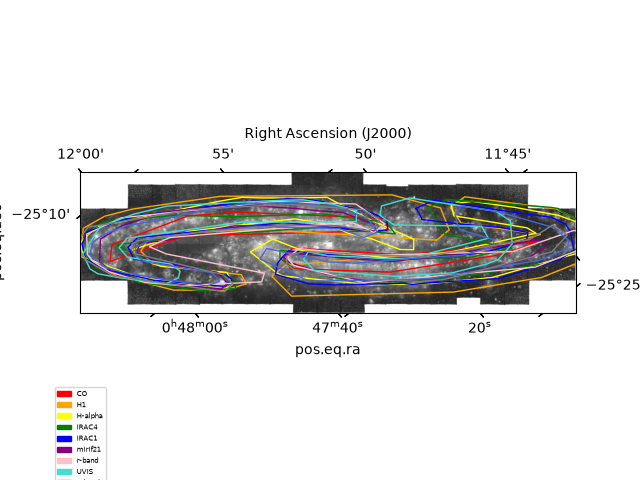

In [3]:
%matplotlib widget
ha_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_Ha.fits"
ha_data = DisplayData(ha_file)

co_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_co_regionfile_aca.reg"
h1_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_h1_regionfile_meerkat.reg"
ha_spiralarms_regionfile =  r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_ha_regionfile_muse.reg"
irac4_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_irac4_regionfile_spitzer.reg"
irac1_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_irac1_regionfile_spitzer.reg"
mirif21_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_mirif21_regionfile_jwst.reg"
rband_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_rband_regionfile_wfi.reg"
uvis_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_uvis_regionfile_hst.reg"
vband_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_vband_regionfile_muse.reg"
w1_spiralarms_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_w1_regionfile_wise.reg"

ha_data.plot_region(ha_file, 
                    
                    co_spiralarms_regionfile, h1_spiralarms_regionfile, ha_spiralarms_regionfile, irac4_spiralarms_regionfile,
                    irac1_spiralarms_regionfile, mirif21_spiralarms_regionfile, rband_spiralarms_regionfile, uvis_spiralarms_regionfile,
                    vband_spiralarms_regionfile, w1_spiralarms_regionfile, 

                    norm = 'log', vmin=30, vmax=30000, figname='ha spiral arm regions')